# Pilot Set — IAA & Bluesky Precision Analysis
**NeurIPS Paper · MPI SWS**

Covers:
1. Posts Ines and adash both labeled (from main survey + pilot_remaining)
2. IAA — agreement and Cohen's κ
3. Bluesky precision per label category (recall not applicable — all pilot posts are Bluesky-flagged unsafe)
4. Disagreement breakdown

## 1. Setup

In [3]:
import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                             classification_report)
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

ANN_PATH = "Bluesky Moderation Annotations.csv"
PILOT_1K      = "pilot_1k.jsonl"
PILOT_REM     = "pilot_remaining.jsonl"

## 2. Load Data

In [4]:
ann = pd.read_csv(ANN_PATH)
ann.columns = ann.columns.str.strip()
ann = ann.drop_duplicates(subset=['annotator_name','post_id'], keep='last')

# Main survey (display_num < 10000) + pilot_remaining (20000-30000)
main_ann     = ann[ann['display_num'] < 10000].copy()
pilot_rem_ann= ann[(ann['display_num'] >= 20000) & (ann['display_num'] < 30000)].copy()
combined_ann = pd.concat([main_ann, pilot_rem_ann], ignore_index=True)

print("Annotations per annotator (main + pilot_remaining):")
print(combined_ann.groupby('annotator_name').size().to_string())

# Load pilot posts metadata (Bluesky labels)
pilot_posts = {}
for path in [PILOT_1K, PILOT_REM]:
    try:
        with open(path) as f:
            for line in f:
                if line.strip():
                    p = json.loads(line)
                    if p.get('uri'): pilot_posts[p['uri']] = p
        print(f"Loaded from {path.split('/')[-1]}: {len(pilot_posts)} total")
    except FileNotFoundError:
        print(f"Not found: {path}")

print(f"\nTotal pilot posts loaded: {len(pilot_posts)}")
print(f"Bluesky label distribution:")
from collections import Counter
lbl_counts = Counter(p.get('label','') for p in pilot_posts.values())
for k,v in lbl_counts.most_common():
    print(f"  {k}: {v}")


Annotations per annotator (main + pilot_remaining):
annotator_name
Ines        1101
adash       1135
soumidas     100
Loaded from pilot_1k.jsonl: 1000 total
Loaded from pilot_remaining.jsonl: 1000 total

Total pilot posts loaded: 1000
Bluesky label distribution:
  rude: 112
  intolerant: 111
  threat: 111
  sexual: 111
  porn: 111
  nudity: 111
  sexual-figurative: 111
  self-harm: 111
  graphic-media: 111


In [5]:
def build_lookup(df, name):
    sub = df[df['annotator_name']==name].drop_duplicates('post_id', keep='last')
    return dict(zip(sub['post_id'], sub['label']))

lu_ines  = build_lookup(combined_ann, 'Ines')
lu_adash = build_lookup(combined_ann, 'adash')

# Keep only pilot posts
pilot_ines  = {u:l for u,l in lu_ines.items()  if u in pilot_posts}
pilot_adash = {u:l for u,l in lu_adash.items() if u in pilot_posts}

common = sorted(set(pilot_ines) & set(pilot_adash))
print(f"Pilot posts labeled by both Ines and adash: {len(common)}")
print(f"  Ines labeled:  {len(pilot_ines)}")
print(f"  adash labeled: {len(pilot_adash)}")


Pilot posts labeled by both Ines and adash: 573
  Ines labeled:  573
  adash labeled: 607


## 3. Label Distribution

In [7]:
# Filter combined_ann to pilot posts only
pilot_ann = combined_ann[combined_ann['post_id'].isin(pilot_posts)].copy()
pilot_ann['bsky_label'] = pilot_ann['post_id'].map(
    lambda u: pilot_posts.get(u,{}).get('label','') or '')

dist = pilot_ann.groupby(['annotator_name','label']).size().unstack(fill_value=0)
dist['total']    = dist.sum(axis=1)
dist['% unsafe'] = (dist.get('Unsafe',0)/dist['total']*100).round(1)
print("Label distribution (pilot posts only):")
print(dist)

print(f"\nBluesky label distribution in annotated pilot posts:")
print(pilot_ann[pilot_ann['annotator_name']=='Ines']['bsky_label'].value_counts().to_string())


Label distribution (pilot posts only):
label           Safe  Unsafe  total  % unsafe
annotator_name                               
Ines             130     443    573      77.3
adash             93     514    607      84.7
soumidas           6      28     34      82.4

Bluesky label distribution in annotated pilot posts:
bsky_label
intolerant           70
rude                 67
nudity               65
graphic-media        65
porn                 63
self-harm            63
sexual-figurative    62
threat               60
sexual               58


## 4. Inter-Annotator Agreement

In [8]:
cats = ['Safe','Unsafe']
la = [pilot_ines[p]  for p in common]
lb = [pilot_adash[p] for p in common]

agree = sum(x==y for x,y in zip(la,lb))
kappa = cohen_kappa_score(la, lb)
interp = ('almost perfect' if kappa>=0.8 else 'substantial' if kappa>=0.6
          else 'moderate' if kappa>=0.4 else 'fair' if kappa>=0.2 else 'poor')

print(f"=== PILOT IAA (n={len(common)}) ===\n")
print(f"Agreement: {agree}/{len(common)} ({100*agree/len(common):.1f}%)")
print(f"Cohen's κ: {kappa:.3f} ({interp})")
print(f"Disagreements: {len(common)-agree}\n")
print(classification_report(la, lb, target_names=['Safe','Unsafe']))


=== PILOT IAA (n=573) ===

Agreement: 464/573 (81.0%)
Cohen's κ: 0.393 (fair)
Disagreements: 109

              precision    recall  f1-score   support

        Safe       0.62      0.43      0.51       130
      Unsafe       0.85      0.92      0.88       443

    accuracy                           0.81       573
   macro avg       0.73      0.68      0.69       573
weighted avg       0.79      0.81      0.80       573



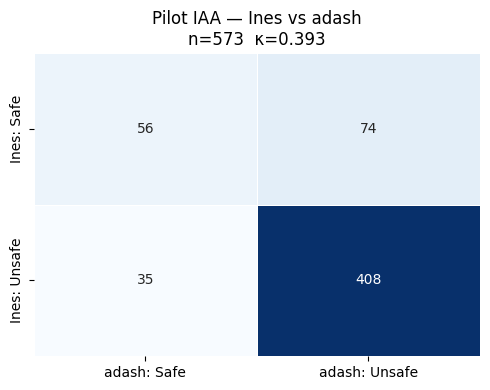

In [9]:
fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(la, lb, labels=cats)
sns.heatmap(pd.DataFrame(cm,
    index=['Ines: Safe','Ines: Unsafe'],
    columns=['adash: Safe','adash: Unsafe']),
    annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
    linewidths=0.5, linecolor='white')
ax.set_title(f'Pilot IAA — Ines vs adash\nn={len(common)}  κ={kappa:.3f}')
plt.tight_layout()
plt.savefig('pilot_iaa.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Bluesky Precision per Label Category

All pilot posts are Bluesky-flagged unsafe. So:
- **Precision** = of posts Bluesky tagged with label X, what fraction did humans confirm as Unsafe?
- **Recall** = not applicable (no safe posts in this sample to compute denominator)

In [10]:
# Build per-post Bluesky label lookup
bsky_label_map = {u: pilot_posts[u].get('label','') for u in pilot_posts}

# Join to annotations
def get_pilot_cats(df, name):
    sub = df[df['annotator_name']==name].drop_duplicates('post_id', keep='last')
    return dict(zip(sub['post_id'], sub['unsafe_categories'].fillna('')))

cats_ines  = get_pilot_cats(pilot_ann, 'Ines')
cats_adash = get_pilot_cats(pilot_ann, 'adash')

all_bsky_labels = sorted(set(
    bsky_label_map[u] for u in common if bsky_label_map.get(u)))

print("=== BLUESKY PRECISION PER LABEL (Human=ground truth) ===\n")
print("Note: ALL posts are Bluesky-flagged. Precision = humans who agreed it's unsafe.\n")

rows = []
for name, lu, cats_lu in [('Ines',pilot_ines,cats_ines),
                           ('adash',pilot_adash,cats_adash)]:
    print(f"--- {name} ---")
    # Overall
    sub_common = [p for p in common if p in lu]
    n_unsafe = sum(1 for p in sub_common if lu[p]=='Unsafe')
    n_safe   = len(sub_common) - n_unsafe
    overall_prec = n_unsafe/len(sub_common)
    print(f"  Overall: n={len(sub_common)}  unsafe={n_unsafe} ({100*n_unsafe/len(sub_common):.1f}%)  "
          f"safe={n_safe}  precision={overall_prec:.3f}\n")

    for lbl in all_bsky_labels:
        if not lbl: continue
        tagged = [p for p in sub_common if bsky_label_map.get(p)==lbl]
        if not tagged: continue
        n_u  = sum(1 for p in tagged if lu[p]=='Unsafe')
        prec = n_u/len(tagged)
        print(f"  {lbl:<22} n={len(tagged):>3}  unsafe={n_u:>3}  safe={len(tagged)-n_u:>3}  precision={prec:.3f}")
        rows.append({'Annotator':name,'Bluesky label':lbl,'n':len(tagged),
                     'Confirmed Unsafe':n_u,'Labeled Safe':len(tagged)-n_u,
                     'Precision':round(prec,3)})
    print()

prec_df = pd.DataFrame(rows)
prec_df


=== BLUESKY PRECISION PER LABEL (Human=ground truth) ===

Note: ALL posts are Bluesky-flagged. Precision = humans who agreed it's unsafe.

--- Ines ---
  Overall: n=573  unsafe=443 (77.3%)  safe=130  precision=0.773

  graphic-media          n= 65  unsafe= 50  safe= 15  precision=0.769
  intolerant             n= 70  unsafe= 40  safe= 30  precision=0.571
  nudity                 n= 65  unsafe= 61  safe=  4  precision=0.938
  porn                   n= 63  unsafe= 63  safe=  0  precision=1.000
  rude                   n= 67  unsafe= 29  safe= 38  precision=0.433
  self-harm              n= 63  unsafe= 50  safe= 13  precision=0.794
  sexual                 n= 58  unsafe= 48  safe= 10  precision=0.828
  sexual-figurative      n= 62  unsafe= 58  safe=  4  precision=0.935
  threat                 n= 60  unsafe= 44  safe= 16  precision=0.733

--- adash ---
  Overall: n=573  unsafe=482 (84.1%)  safe=91  precision=0.841

  graphic-media          n= 65  unsafe= 54  safe= 11  precision=0.831
  in

,Annotator,Bluesky label,n,Confirmed Unsafe,Labeled Safe,Precision
0,Ines,graphic-media,65,50,15,0.769
1,Ines,intolerant,70,40,30,0.571
2,Ines,nudity,65,61,4,0.938
3,Ines,porn,63,63,0,1.000
4,Ines,rude,67,29,38,0.433
5,Ines,self-harm,63,50,13,0.794
6,Ines,sexual,58,48,10,0.828
7,Ines,sexual-figurative,62,58,4,0.935
8,Ines,threat,60,44,16,0.733
9,adash,graphic-media,65,54,11,0.831


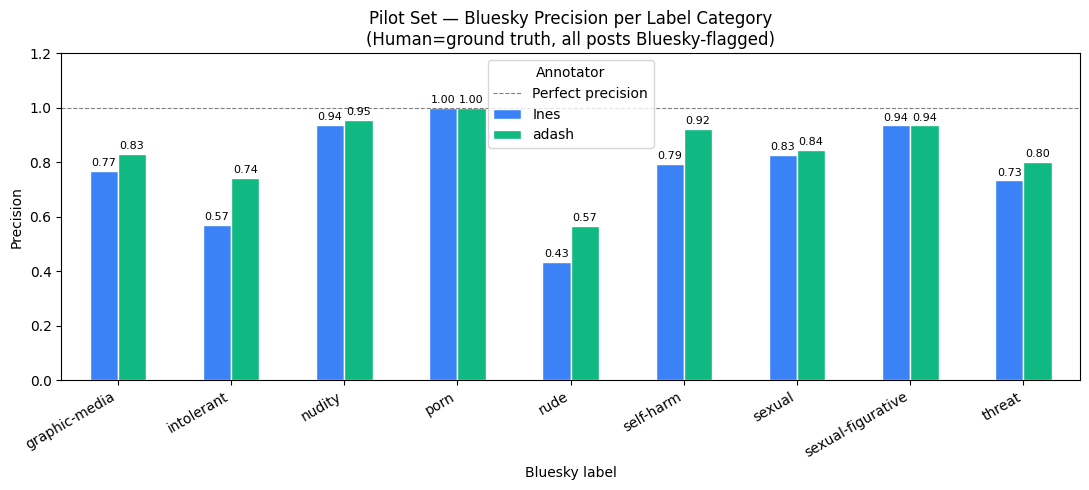

Saved → pilot_precision_per_label.csv


In [11]:
# Bar chart
if len(prec_df):
    pivot = prec_df.pivot(index='Bluesky label', columns='Annotator',
                          values='Precision').fillna(0)
    ax = pivot.plot(kind='bar', figsize=(11,5),
                    color=['#3b82f6','#10b981'], edgecolor='white')
    plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Perfect precision')
    plt.title('Pilot Set — Bluesky Precision per Label Category\n(Human=ground truth, all posts Bluesky-flagged)')
    plt.ylabel('Precision')
    plt.ylim(0, 1.2)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Annotator')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
    plt.tight_layout()
    plt.savefig('pilot_precision_per_label.png', dpi=150, bbox_inches='tight')
    plt.show()

prec_df.to_csv('pilot_precision_per_label.csv', index=False)
print("Saved → pilot_precision_per_label.csv")


## 6. Disagreements

In [12]:
disagree = [p for p in common if pilot_ines[p] != pilot_adash[p]]
print(f"Disagreements: {len(disagree)} / {len(common)} ({100*len(disagree)/len(common):.1f}%)\n")

print("Breakdown:")
ines_unsafe_adash_safe = sum(1 for p in disagree if pilot_ines[p]=='Unsafe')
ines_safe_adash_unsafe = sum(1 for p in disagree if pilot_adash[p]=='Unsafe')
print(f"  Ines=Unsafe, adash=Safe: {ines_unsafe_adash_safe}")
print(f"  Ines=Safe, adash=Unsafe: {ines_safe_adash_unsafe}")

print("\nDisagreement by Bluesky label:")
dis_lbls = Counter(bsky_label_map.get(p,'?') for p in disagree)
for k,v in dis_lbls.most_common():
    print(f"  {k}: {v}")

# Detail table
rows = []
for p in disagree:
    post = pilot_posts.get(p,{})
    rows.append({
        'bsky_label':    bsky_label_map.get(p,''),
        'Ines':          pilot_ines[p],
        'adash':         pilot_adash[p],
        'Ines_cats':     cats_ines.get(p,''),
        'adash_cats':    cats_adash.get(p,''),
        'text':          str(post.get('text',''))[:100],
        'uri':           p,
    })
dis_df = pd.DataFrame(rows)
dis_df.to_csv('pilot_disagreements_detail.csv', index=False)
print(f"\nSaved {len(dis_df)} disagreements → pilot_disagreements_detail.csv")
dis_df


Disagreements: 109 / 573 (19.0%)

Breakdown:
  Ines=Unsafe, adash=Safe: 35
  Ines=Safe, adash=Unsafe: 74

Disagreement by Bluesky label:
  rude: 29
  intolerant: 26
  threat: 18
  graphic-media: 14
  self-harm: 8
  sexual: 7
  sexual-figurative: 4
  nudity: 3

Saved 109 disagreements → pilot_disagreements_detail.csv


,bsky_label,Ines,adash,Ines_cats,adash_cats,text,uri
0,graphic-media,Unsafe,Safe,S7,,Day 27: THE GIRL WITH ALL THE GIFTS (2016)\nA pretty good film that lost to ...,at://did:plc:24vdmhn7s5isus47tf36fjk7/app.bsky.feed.post/3m4a2ndxbtc2z
1,threat,Unsafe,Safe,S9,,israeli PM stroked the orange snollygosters ego and that got Iran bombed by ...,at://did:plc:2nddvcj4gfgaqc6he35ffkhf/app.bsky.feed.post/3ls5wsf4xjk2w
2,nudity,Safe,Unsafe,,S5,"Thank you @emmaexhibition.bsky.social for the beautiful reference, and for c...",at://did:plc:2oow4uik7eoze4cg5qyrtci5/app.bsky.feed.post/3lo4nul75g22x
3,rude,Safe,Unsafe,,S8,"Where are you fucking from, goofball? It’s definitely not the US. If it were...",at://did:plc:3a3xm3q65hflnxpi2ebr7r7j/app.bsky.feed.post/3lvppi3mlgc26
4,intolerant,Safe,Unsafe,,S6,"Fuck off, christians with tiny penises.",at://did:plc:3clmel6lxx56n44hsf5jfv6q/app.bsky.feed.post/3lvyled6yxc24
...,...,...,...,...,...,...,...
104,intolerant,Safe,Unsafe,,S8,"It's all for fun, you moron. Look up autogynephilia.",at://did:plc:xsa7pqi5mnso4y7fswsl5yai/app.bsky.feed.post/3lwp4hrsrcs2w
105,sexual,Safe,Unsafe,,S3,Alberto Martini,at://did:plc:xsawiprup5fxw7tchcyn3d37/app.bsky.feed.post/3mau6775n4k2o
106,threat,Safe,Unsafe,,"S8,S9",Another person who just needs to stop breathing,at://did:plc:y5lsw44bhe2untar7ywsp45y/app.bsky.feed.post/3lj4xyjd5fs2x
107,rude,Safe,Unsafe,,S8,Fuck you.,at://did:plc:ynztc2a5bsj7lwk4k3pji466/app.bsky.feed.post/3lxpzor3mfk2h


## 7. Summary

In [13]:
print("=== PILOT ANALYSIS SUMMARY ===\n")
print(f"Posts labeled by both:     {len(common)}")
print(f"Agreement:                 {agree}/{len(common)} ({100*agree/len(common):.1f}%)")
print(f"Cohen's κ:                 {kappa:.3f} ({interp})")
print(f"Disagreements:             {len(disagree)}")
print()
print("Bluesky precision (overall):")
for name, lu in [('Ines',pilot_ines),('adash',pilot_adash)]:
    sub = [p for p in common if p in lu]
    n_u = sum(1 for p in sub if lu[p]=='Unsafe')
    print(f"  {name}: {n_u}/{len(sub)} confirmed unsafe ({100*n_u/len(sub):.1f}%)  precision={n_u/len(sub):.3f}")
print()
print("Mean precision per label:")
print(prec_df.groupby('Annotator')['Precision'].mean().round(3).to_string())


=== PILOT ANALYSIS SUMMARY ===

Posts labeled by both:     573
Agreement:                 464/573 (81.0%)
Cohen's κ:                 0.393 (fair)
Disagreements:             109

Bluesky precision (overall):
  Ines: 443/573 confirmed unsafe (77.3%)  precision=0.773
  adash: 482/573 confirmed unsafe (84.1%)  precision=0.841

Mean precision per label:
Annotator
Ines     0.778
adash    0.844
